# 당뇨 예측 - CatBoost Optuna

- 타겟: `당뇨유병` (0: 없음 / 1: 있음)
- 모델: CatBoost + Optuna TPE Sampler
- 데이터: `hn_all_preprocessed_v4.csv` (15~24년 통합)
- Threshold: **0.50 고정**
- FE: 미적용
- 목표: **Recall ≥ 0.80 유지하면서 F1 최대화**
- 검증: Stratified 5-Fold CV

In [2]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR  = os.path.dirname(os.path.abspath(''))
BASE_DIR     = os.path.join(CURRENT_DIR, '..')
DATA_PATH    = os.path.join(BASE_DIR, 'data', 'hn_all_preprocessed_v4.csv')
FEATURES_DIR = os.path.join(BASE_DIR, 'features')
NPY_DIR      = os.path.join(BASE_DIR, 'outputs', 'oof')
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD    = 0.50
N_TRIALS     = 100


## 1. 데이터 로드

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'로드 완료 | shape: {df.shape}')

로드 완료 | shape: (22102, 31)


## 2. ✏️ Feature Engineering 설정

In [4]:
# ── 피처 엔지니어링 함수 import ──────────────────────────────

# ── 적용할 피처 선택 (주석 해제 = 적용) ──────────────────────
# df = add_age_bin(df, drop_original=False)                  # 나이_구간
# df = add_age_bin5(df, drop_original=False)                 # 나이_5구간

# 가족력 실험
# df = add_family_sum(df, diabetes=True, hypertension=False, dyslipidemia=False,
#                     drop_original=True) # 가족력_3종_제거 + 가족력_합산
# df = df.drop(columns=[
#     '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제',
#     '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제',]) # 가족력 실험

# BMI 실험
# df = add_bmi_bin(df, korean_standard=True, drop_original=True) # BMI_구간(True: 한국인 기준, False: WHO 기준)
# df = df.drop(columns=[ '키', '체중',]) # BMI 실험

# df = add_alcohol_load(df, drop_original=True)  # 음주_총부하 (필요 시 해제)
# df = add_exercise_total(df, drop_original=False)         # 총운동일수 (필요 시 해제)
# df = add_body_features(df, weight_height_ratio=True, bmi_age_interaction=False, drop_original=True) # 체형 복합 (필요 시 해제)
# df = add_age_family_interaction(df, hypertension=False, diabetes=True)   # 나이×가족력 (필요 시 해제)


print(f'\n피처 엔지니어링 완료 | shape: {df.shape}')


피처 엔지니어링 완료 | shape: (22102, 31)


## 3. 피처 / 타겟 분리

In [5]:
TARGET    = '당뇨유병'
DROP_COLS = ['고혈압유병', '당뇨유병', '이상지질혈증유병']

data  = df.dropna(subset=[TARGET]).copy()
X     = data.drop(columns=DROP_COLS)
y     = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f'샘플 수: {len(y)}  |  정상: {neg}  |  당뇨: {pos}')
print(f'불균형 비율: {ratio:.4f}:1')
print(f'사용 피처 수: {X.shape[1]}')

샘플 수: 22050  |  정상: 15732  |  당뇨: 6318
불균형 비율: 2.4900:1
사용 피처 수: 28


## 4. Optuna Objective 정의

In [6]:
def objective(trial):
    params = dict(
        iterations          = trial.suggest_int('iterations', 300, 800),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth               = trial.suggest_int('depth', 3, 8),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 0.0, 1.0),
        border_count        = trial.suggest_int('border_count', 32, 255),
        loss_function         = 'Logloss',
        eval_metric           = 'AUC',
        class_weights         = {0: 1.0, 1: ratio},
        early_stopping_rounds = 50,
        random_seed           = RANDOM_STATE,
        verbose               = False,
        allow_writing_files   = False,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in cv.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(Pool(X.iloc[tr_idx], y.iloc[tr_idx]),
              eval_set=Pool(X.iloc[val_idx], y.iloc[val_idx]))
        proba   = m.predict_proba(X.iloc[val_idx])[:, 1]
        pred    = (proba >= THRESHOLD).astype(int)
        rec     = recall_score(y.iloc[val_idx], pred)
        penalty = max(0, 0.8 - rec) * 2
        scores.append(f1_score(y.iloc[val_idx], pred) - penalty)
    return np.mean(scores)

## 5. Optuna 최적화 실행

In [7]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n최적 trial: {study.best_trial.number}')
print(f'최적 score: {study.best_value:.4f}')
print('\n[최적 파라미터]')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Best trial: 93. Best value: 0.603669: 100%|██████████| 100/100 [15:52<00:00,  9.52s/it]


최적 trial: 93
최적 score: 0.6037

[최적 파라미터]
  iterations: 585
  learning_rate: 0.03417929367057629
  depth: 5
  l2_leaf_reg: 4.210544242744235
  bagging_temperature: 0.35554454697929566
  random_strength: 0.9045504755091893
  border_count: 115


## 6. Optuna 최적화 과정 시각화

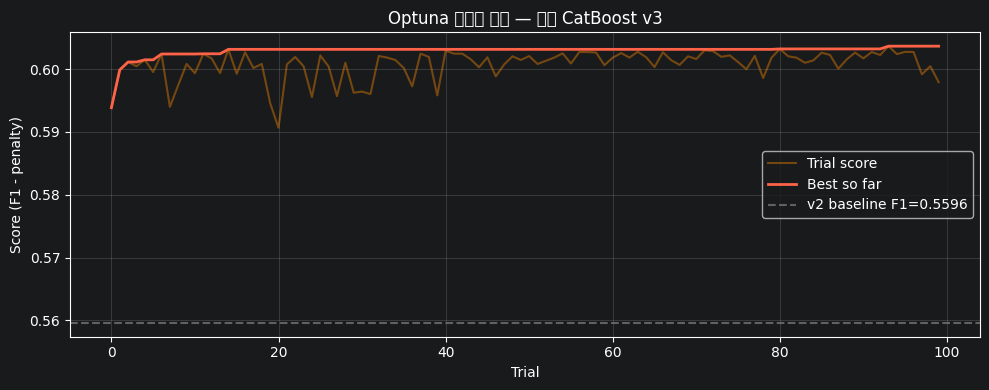

In [8]:
trial_values = [t.value for t in study.trials]
best_so_far  = np.maximum.accumulate(trial_values)

plt.figure(figsize=(10, 4))
plt.plot(trial_values, alpha=0.4, color='darkorange', label='Trial score')
plt.plot(best_so_far,  color='tomato', lw=2, label='Best so far')
plt.axhline(y=0.5596, color='gray', linestyle='--', alpha=0.7,
            label='v2 baseline F1=0.5596')
plt.xlabel('Trial')
plt.ylabel('Score (F1 - penalty)')
plt.title('Optuna 최적화 과정 — 당뇨 CatBoost v3')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 최적 파라미터로 최종 학습 & 평가

In [9]:
best_params = dict(**study.best_params,
    loss_function         = 'Logloss',
    eval_metric           = 'AUC',
    class_weights         = {0: 1.0, 1: ratio},
    early_stopping_rounds = 50,
    random_seed           = RANDOM_STATE,
    verbose               = False,
    allow_writing_files   = False,
)

skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba   = np.zeros(len(y))
fold_scores = []

print('=' * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = CatBoostClassifier(**best_params)
    model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred  = (proba >= THRESHOLD).astype(int)
    cm_f  = confusion_matrix(y_val, pred)
    fold_scores.append({
        'fold': fold,
        'auc':       roc_auc_score(y_val, proba),
        'f1':        f1_score(y_val, pred),
        'recall':    recall_score(y_val, pred),
        'precision': precision_score(y_val, pred),
        'fp':        int(cm_f[0, 1]),
        'best_iter': model.best_iteration_,
    })
    print(f'  Fold {fold} | AUC: {fold_scores[-1]["auc"]:.4f} | '
          f'Recall: {fold_scores[-1]["recall"]:.4f} | '
          f'F1: {fold_scores[-1]["f1"]:.4f} | '
          f'best_iter: {model.best_iteration_}')

scores_df = pd.DataFrame(fold_scores)
print('=' * 65)
print(f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
      f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
      f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}")

  Fold 1 | AUC: 0.8038 | Recall: 0.8052 | F1: 0.6009 | best_iter: 351
  Fold 2 | AUC: 0.8078 | Recall: 0.8211 | F1: 0.6013 | best_iter: 291
  Fold 3 | AUC: 0.7947 | Recall: 0.8022 | F1: 0.5961 | best_iter: 346
  Fold 4 | AUC: 0.8106 | Recall: 0.8188 | F1: 0.6108 | best_iter: 491
  Fold 5 | AUC: 0.8165 | Recall: 0.8220 | F1: 0.6092 | best_iter: 500
  평균   | AUC: 0.8067±0.0081 | Recall: 0.8139±0.0094 | F1: 0.6037±0.0062


## 8. OOF proba 저장 (.npy)

In [10]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path  = os.path.join(NPY_DIR, 'oof_proba_DM_catboost_v3_optuna.npy')
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f'저장 완료 → {npy_path}')
loaded = np.load(npy_path)
print(f'로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}')

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_DM_catboost_v3_optuna.npy
로드 확인: shape=(22050, 2), 일치=True


## 9. OOF 전체 성능 & v2 baseline 비교

In [11]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm       = confusion_matrix(y, pred_oof)
oof_auc  = roc_auc_score(y, oof_proba)
oof_rec  = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1   = f1_score(y, pred_oof)
oof_acc  = float((pred_oof == y).mean())

# v2 baseline (Optuna 파라미터 고정, FE 없음)
BASE = {'auc': 0.8059, 'recall': 0.8148, 'precision': 0.4776,
        'f1': 0.6022, 'acc': 0.6916, 'fp': 5631, 'fn': 1170}

print('=' * 58)
print(f'  {"지표":<12}  {"v2 baseline":>12}  {"v3 Optuna":>10}  변화')
print('=' * 58)
for label, base_v, cur_v in [
    ('AUC-ROC',   BASE['auc'],       oof_auc ),
    ('Recall',    BASE['recall'],    oof_rec ),
    ('Precision', BASE['precision'], oof_prec),
    ('F1-score',  BASE['f1'],        oof_f1  ),
    ('Accuracy',  BASE['acc'],       oof_acc ),
]:
    d = cur_v - base_v
    arrow = '▲' if d > 0 else ('▼' if d < 0 else '─')
    print(f'  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}')
print(f'  {"FP":<12}  {BASE["fp"]:>12}  {cm[0,1]:>10}  {"▼" if cm[0,1]<BASE["fp"] else "▲"} {abs(cm[0,1]-BASE["fp"])}')
print(f'  {"FN":<12}  {BASE["fn"]:>12}  {cm[1,0]:>10}  {"▼" if cm[1,0]<BASE["fn"] else "▲"} {abs(cm[1,0]-BASE["fn"])}')
print('=' * 58)
print('\n[분류 리포트]')
print(classification_report(y, pred_oof, target_names=['정상(0)', '당뇨(1)']))

  지표             v2 baseline   v3 Optuna  변화
  AUC-ROC             0.8059      0.8067  ▲ 0.0008
  Recall              0.8148      0.8139  ▼ 0.0009
  Precision           0.4776      0.4798  ▲ 0.0022
  F1-score            0.6022      0.6037  ▲ 0.0015
  Accuracy            0.6916      0.6938  ▲ 0.0022
  FP                    5631        5576  ▼ 55
  FN                    1170        1176  ▲ 6

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.90      0.65      0.75     15732
       당뇨(1)       0.48      0.81      0.60      6318

    accuracy                           0.69     22050
   macro avg       0.69      0.73      0.68     22050
weighted avg       0.78      0.69      0.71     22050



## 10. Confusion Matrix

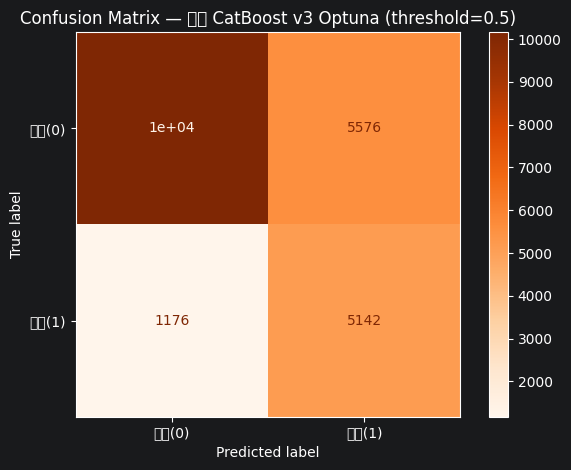

In [12]:
disp = ConfusionMatrixDisplay(cm, display_labels=['정상(0)', '당뇨(1)'])
disp.plot(cmap='Oranges')
plt.title(f'Confusion Matrix — 당뇨 CatBoost v3 Optuna (threshold={THRESHOLD})')
plt.tight_layout()
plt.show()

## 11. Feature Importance (5-Fold 평균)

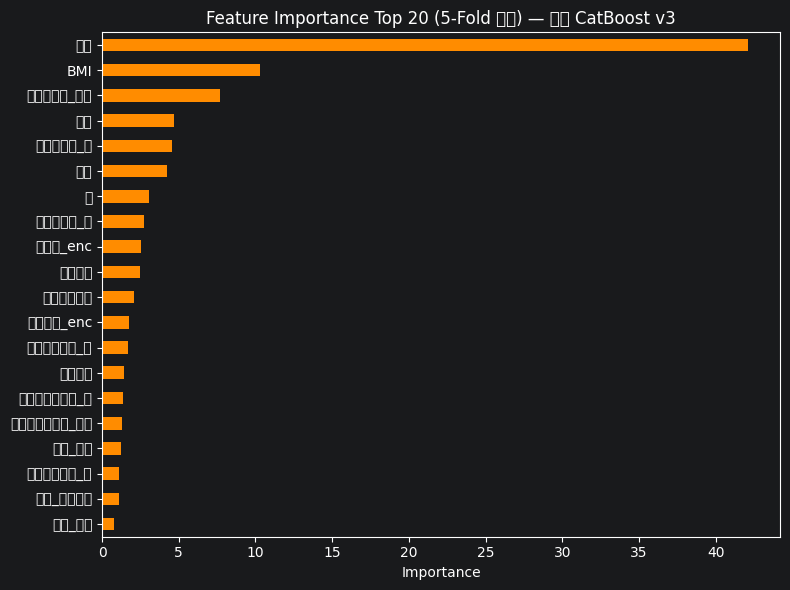

나이            42.090766
BMI           10.269877
당뇨가족력_형제       7.686814
체중             4.682124
당뇨가족력_모        4.527459
성별             4.241406
키              3.052748
당뇨가족력_부        2.725647
음주량_enc        2.542151
걷기일수           2.493800
근력운동일수         2.047508
음주빈도_enc       1.780551
고혈압가족력_모       1.672722
현재흡연           1.440221
고지혈증가족력_모      1.366036
고지혈증가족력_형제     1.290449
직업_무직          1.227758
고혈압가족력_부       1.111953
직업_관리전문        1.073572
직업_사무          0.793600


In [13]:
fi_list = []
for fold, (tr_idx, val_idx) in enumerate(
        StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y), 1):
    m = CatBoostClassifier(**best_params)
    m.fit(Pool(X.iloc[tr_idx], y.iloc[tr_idx]),
          eval_set=Pool(X.iloc[val_idx], y.iloc[val_idx]))
    fi_list.append(m.get_feature_importance())

fi = pd.DataFrame(fi_list, columns=X.columns).mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.head(20)[::-1].plot(kind='barh', color='darkorange')
plt.title('Feature Importance Top 20 (5-Fold 평균) — 당뇨 CatBoost v3')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(fi.head(20).to_string())

## 12. SHAP 분석 (OOF 전체 기준)

SHAP Fold 1 완료
SHAP Fold 2 완료
SHAP Fold 3 완료
SHAP Fold 4 완료
SHAP Fold 5 완료


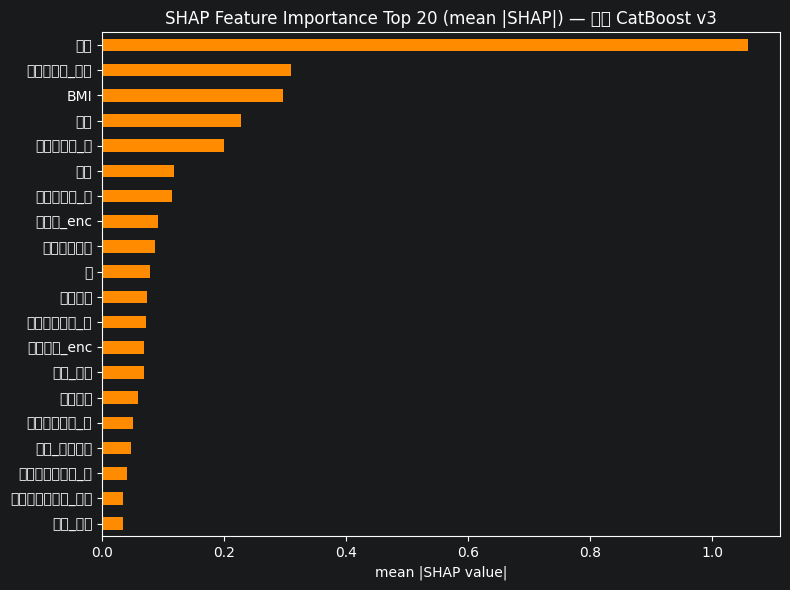

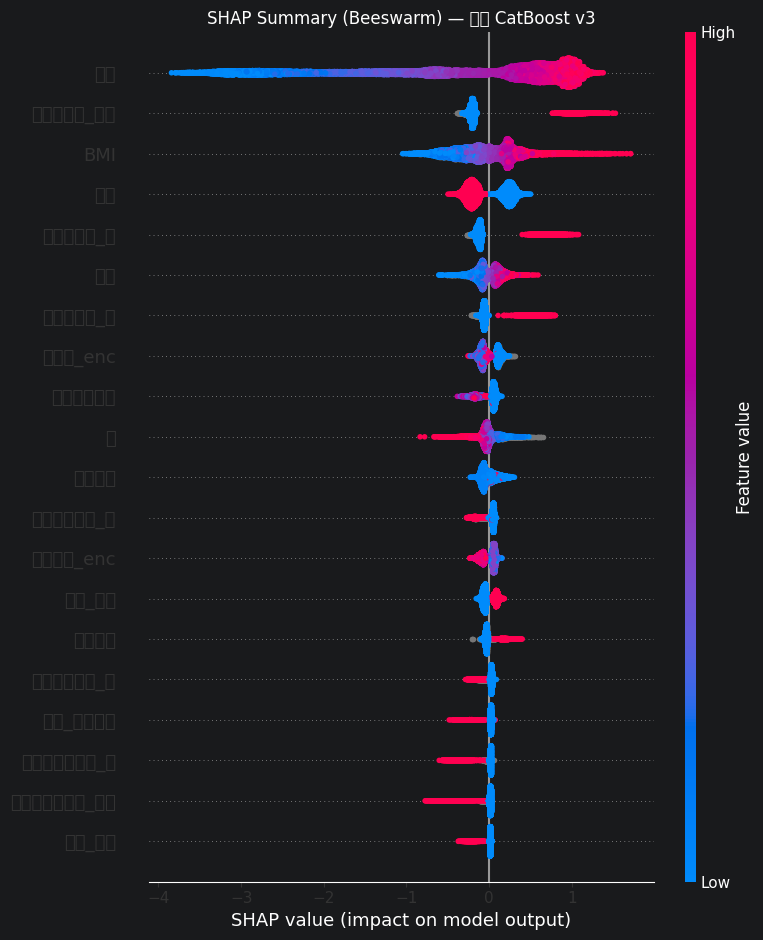

[SHAP Top 15]
   1. 나이: 1.0584
   2. 당뇨가족력_형제: 0.3091
   3. BMI: 0.2970
   4. 성별: 0.2284
   5. 당뇨가족력_모: 0.2002
   6. 체중: 0.1174
   7. 당뇨가족력_부: 0.1140
   8. 음주량_enc: 0.0923
   9. 근력운동일수: 0.0871
  10. 키: 0.0780
  11. 걷기일수: 0.0736
  12. 고혈압가족력_모: 0.0726
  13. 음주빈도_enc: 0.0690
  14. 직업_무직: 0.0681
  15. 현재흡연: 0.0593


In [14]:
import shap

skf2        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
shap_values = np.zeros(X.shape)

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X, y), 1):
    m = CatBoostClassifier(**best_params)
    m.fit(Pool(X.iloc[tr_idx], y.iloc[tr_idx]),
          eval_set=Pool(X.iloc[val_idx], y.iloc[val_idx]))
    explainer = shap.TreeExplainer(m)
    shap_values[val_idx] = explainer.shap_values(X.iloc[val_idx])
    print(f'SHAP Fold {fold} 완료')

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                      index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind='barh', color='darkorange')
plt.title('SHAP Feature Importance Top 20 (mean |SHAP|) — 당뇨 CatBoost v3')
plt.xlabel('mean |SHAP value|')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X, plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary (Beeswarm) — 당뇨 CatBoost v3', fontsize=12)
plt.tight_layout()
plt.show()

print('[SHAP Top 15]')
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f'  {i:2d}. {feat}: {val:.4f}')

## 13. DB 로그 저장

In [15]:
sys.path.insert(0, BASE_DIR)
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, 'model_result.db'))

base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols   = [c for c in X.columns if c not in base_cols]
fe_note   = f'FE 적용: {fe_cols}' if fe_cols else 'FE 없음'

run_id = logger.log_run(
    target_var  = '당뇨',
    model_name  = 'CatBoost',
    stage       = 'v3_optuna',
    hyperparams = {
        'learning_rate':     best_params['learning_rate'],
        'depth':             best_params['depth'],
        'n_estimators':      best_params['iterations'],
        'class_weight':      {0: 1.0, 1: round(ratio, 4)},
        'l2_leaf_reg':       best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_strength':   best_params['random_strength'],
        'border_count':      best_params['border_count'],
    },
    data_info = {
        'feature_count':    X.shape[1],
        'train_test_split': '5-Fold CV',
        'scaling_method':   'None',
    },
    oof_metrics = {
        'accuracy': oof_acc, 'recall': oof_rec,
        'precision': oof_prec, 'f1_score': oof_f1,
        'auc_roc': oof_auc, 'cm': cm.tolist(),
    },
    fold_scores  = scores_df.to_dict('records'),
    top_features = mean_shap.head(15).to_dict(),
    note = f'v3 Optuna {N_TRIALS} trials. 데이터: hn_all_v2. {fe_note}',
)
print(f'저장 완료 → run_id: {run_id}  |  {fe_note}')
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=124 | 당뇨 CatBoost (v3_optuna)
저장 완료 → run_id: 124  |  FE 없음
 run_id          created_at target_var model_name             stage  auc_roc   recall  precision  f1_score  accuracy
    124 2026-05-20 16:39:55         당뇨   CatBoost         v3_optuna 0.806710 0.813865   0.479754  0.603663  0.693787
    123 2026-05-20 15:44:25     이상지질혈증    XGBoost            fe_exp 0.775057 0.852850   0.471844  0.607555  0.650533
    122 2026-05-20 15:42:20         당뇨   CatBoost            fe_exp 0.805881 0.814815   0.477595  0.602211  0.691565
    121 2026-05-20 15:05:44     이상지질혈증    XGBoost            fe_exp 0.785280 0.855227   0.440314  0.581330  0.650326
    120 2026-05-20 15:04:47     이상지질혈증    XGBoost            fe_exp 0.785628 0.858534   0.440517  0.582269  0.650326
    119 2026-05-20 15:03:06     이상지질혈증    XGBoost            fe_exp 0.785309 0.857799   0.440888  0.582424  0.650847
    118 2026-05-20 14:41:43     이상지질혈증    XGBoost            fe_exp 0.784737 0.855778   0.44